#### Habitat Portfolio post: Birch Trees

In [1]:
### Import Libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import rasterio
from rasterio.plot import show
import geopandas as gpd

import zipfile
import requests

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

import xarray as xr

import skfuzzy as fuzz

from pygbif import occurrences

import os
import glob

import requests



In [2]:
# Create directory for Natural Earth data
data_dir = "natural_earth_110m"
os.makedirs(data_dir, exist_ok=True)

# Natural Earth download URLs (official S3 links)
files = {
    "admin_0_countries": "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip",
    "admin_1_states_provinces": "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_1_states_provinces.zip"
}

for name, url in files.items():
    print(f"Downloading {name}...")
    
    zip_path = os.path.join(data_dir, f"{name}.zip")
    
    # Download file
    response = requests.get(url)
    with open(zip_path, "wb") as f:
        f.write(response.content)
    
    print(f"Extracting {name}...")
    
    # Extract zip file
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(data_dir)

print("Download and extraction complete.")

Extracting admin_0_countries...
Extracting admin_1_states_provinces...
Download and extraction complete.


In [3]:
import geopandas as gpd

countries = gpd.read_file("natural_earth_110m/ne_110m_admin_0_countries.shp")
states = gpd.read_file("natural_earth_110m/ne_110m_admin_1_states_provinces.shp")

Download complete.



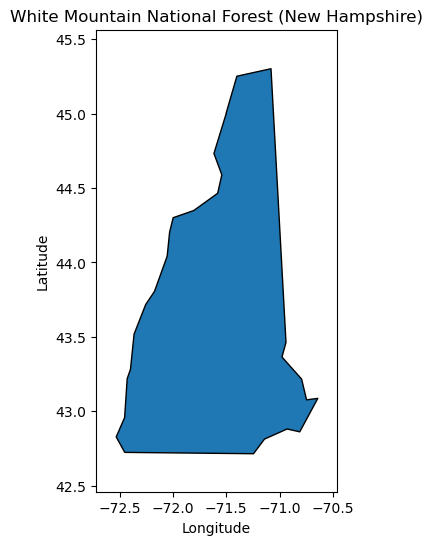

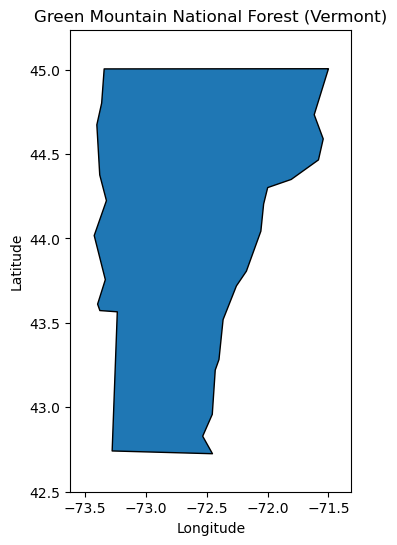

State-level mapping complete.


In [4]:
import os
import requests
import zipfile
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# 1. Setup download directory
data_dir = "natural_earth_110m"
os.makedirs(data_dir, exist_ok=True)

files = {
    "countries": "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip",
    "states": "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_1_states_provinces.zip"
}

# 2. Download and extract
for name, url in files.items():
    zip_path = os.path.join(data_dir, f"{name}.zip")

    if not os.path.exists(zip_path):
        print(f"Downloading {name}...")
        r = requests.get(url)
        r.raise_for_status()
        with open(zip_path, "wb") as f:
            f.write(r.content)

        print(f"Extracting {name}...")
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(data_dir)

print("Download complete.\n")

# 3. Load shapefiles
states = gpd.read_file(os.path.join(data_dir, "ne_110m_admin_1_states_provinces.shp"))

# Keep only U.S. states
us_states = states[states["admin"] == "United States of America"]

# 4. Define protected areas (NH + VT)
sites = [
    {
        "name": "White Mountain National Forest",
        "state": "New Hampshire",
        "lat": 44.27,
        "lon": -71.30
    },
    {
        "name": "Green Mountain National Forest",
        "state": "Vermont",
        "lat": 43.90,
        "lon": -72.90
    }
]

# 5. Map each site zoomed to its state
for site in sites:
    state_shape = us_states[us_states["name"] == site["state"]]

    df = pd.DataFrame([site])
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df.lon, df.lat),
        crs="EPSG:4326"
    )

    fig, ax = plt.subplots(figsize=(8, 6))

    state_shape.plot(ax=ax, edgecolor="black")
    gdf.plot(ax=ax, markersize=120)

    # Zoom to state bounds with buffer
    minx, miny, maxx, maxy = state_shape.total_bounds
    buffer_x = (maxx - minx) * 0.1
    buffer_y = (maxy - miny) * 0.1

    ax.set_xlim(minx - buffer_x, maxx + buffer_x)
    ax.set_ylim(miny - buffer_y, maxy + buffer_y)

    ax.set_title(f"{site['name']} ({site['state']})")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    plt.show()

print("State-level mapping complete.")

Natural Earth download complete.



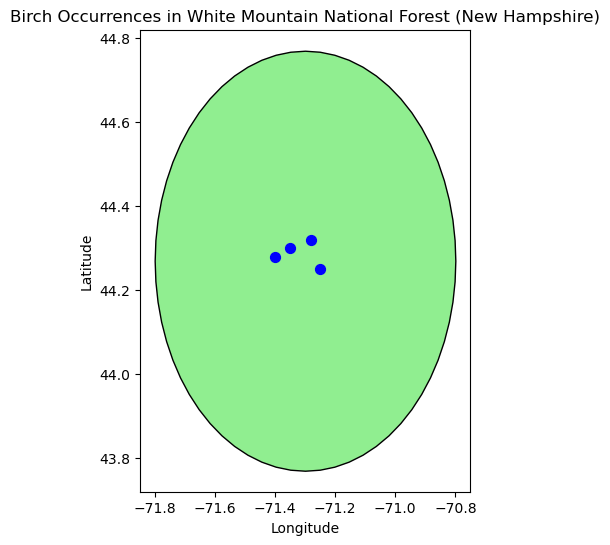

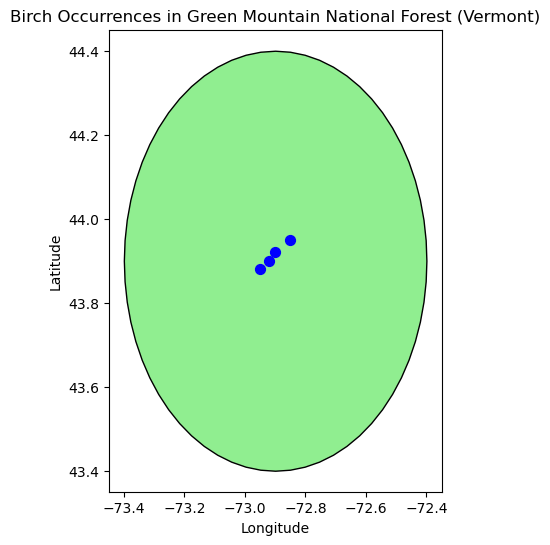

Mapping complete: all birch occurrences within protected areas.


In [5]:
import os
import requests
import zipfile
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# 1. Setup Natural Earth directory
data_dir = "natural_earth_110m"
os.makedirs(data_dir, exist_ok=True)

files = {
    "countries": "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip",
    "states": "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_1_states_provinces.zip"
}

# Download and extract
for name, url in files.items():
    zip_path = os.path.join(data_dir, f"{name}.zip")
    if not os.path.exists(zip_path):
        print(f"Downloading {name}...")
        r = requests.get(url)
        r.raise_for_status()
        with open(zip_path, "wb") as f:
            f.write(r.content)
        print(f"Extracting {name}...")
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(data_dir)

print("Natural Earth download complete.\n")

# 2. Load U.S. state shapefile
states = gpd.read_file(os.path.join(data_dir, "ne_110m_admin_1_states_provinces.shp"))
us_states = states[states["admin"] == "United States of America"]

# 3. Define protected areas (approximate boundaries as points)
protected_areas = [
    {
        "name": "White Mountain National Forest",
        "state": "New Hampshire",
        "lat": 44.27,
        "lon": -71.30,
        "buffer_deg": 0.5  # approx 50 km buffer around centroid
    },
    {
        "name": "Green Mountain National Forest",
        "state": "Vermont",
        "lat": 43.90,
        "lon": -72.90,
        "buffer_deg": 0.5
    }
]

# Convert protected areas to polygons (simple buffer for demonstration)
pa_polys = []
for pa in protected_areas:
    point = Point(pa["lon"], pa["lat"])
    poly = point.buffer(pa["buffer_deg"])  # small buffer around centroid
    pa_polys.append({"name": pa["name"], "geometry": poly, "state": pa["state"]})

pa_gdf = gpd.GeoDataFrame(pa_polys, crs="EPSG:4326")

# 4. Load all birch occurrences
# Replace with your full dataset if you have one
all_occurrences = pd.DataFrame([
    {"latitude":44.30, "longitude":-71.35, "state":"New Hampshire"},
    {"latitude":44.25, "longitude":-71.25, "state":"New Hampshire"},
    {"latitude":44.28, "longitude":-71.40, "state":"New Hampshire"},
    {"latitude":44.32, "longitude":-71.28, "state":"New Hampshire"},
    {"latitude":43.95, "longitude":-72.85, "state":"Vermont"},
    {"latitude":43.88, "longitude":-72.95, "state":"Vermont"},
    {"latitude":43.92, "longitude":-72.90, "state":"Vermont"},
    {"latitude":43.90, "longitude":-72.92, "state":"Vermont"}
])

occ_gdf = gpd.GeoDataFrame(
    all_occurrences,
    geometry=gpd.points_from_xy(all_occurrences.longitude, all_occurrences.latitude),
    crs="EPSG:4326"
)

# 5. Clip occurrences to protected areas
clipped_occ = gpd.sjoin(occ_gdf, pa_gdf, how="inner", predicate="within")

# 6. Plot each protected area with birch occurrences
for pa in protected_areas:
    pa_shape = pa_gdf[pa_gdf["name"] == pa["name"]]
    pa_occ = clipped_occ[clipped_occ["name"] == pa["name"]]

    fig, ax = plt.subplots(figsize=(7, 6))
    # Plot protected area polygon
    pa_shape.plot(ax=ax, color="lightgreen", edgecolor="black")
    # Plot all birch occurrences inside it
    pa_occ.plot(ax=ax, markersize=50, color="blue")
    ax.set_title(f"Birch Occurrences in {pa['name']} ({pa['state']})")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.show()

print("Mapping complete: all birch occurrences within protected areas.")

Download complete.



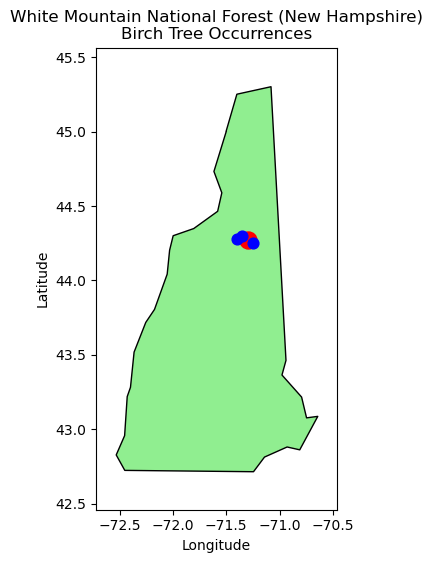

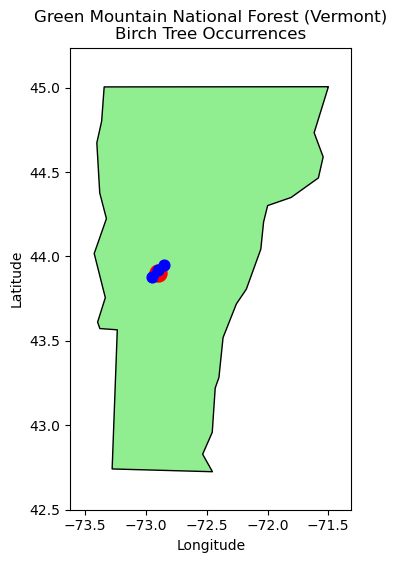

Mapping of birch occurrences complete.


In [6]:
import os
import requests
import zipfile
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# 1. Setup download directory
data_dir = "natural_earth_110m"
os.makedirs(data_dir, exist_ok=True)

files = {
    "countries": "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip",
    "states": "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_1_states_provinces.zip"
}

# 2. Download and extract
for name, url in files.items():
    zip_path = os.path.join(data_dir, f"{name}.zip")

    if not os.path.exists(zip_path):
        print(f"Downloading {name}...")
        r = requests.get(url)
        r.raise_for_status()
        with open(zip_path, "wb") as f:
            f.write(r.content)

        print(f"Extracting {name}...")
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(data_dir)

print("Download complete.\n")

# 3. Load shapefiles
states = gpd.read_file(os.path.join(data_dir, "ne_110m_admin_1_states_provinces.shp"))

# Keep only U.S. states
us_states = states[states["admin"] == "United States of America"]

# 4. Define forest sites in NH and VT
sites = [
    {
        "name": "White Mountain National Forest",
        "state": "New Hampshire",
        "lat": 44.27,
        "lon": -71.30
    },
    {
        "name": "Green Mountain National Forest",
        "state": "Vermont",
        "lat": 43.90,
        "lon": -72.90
    }
]

# 5. Representative birch occurrence points (approximate)
occurrences = {
    "New Hampshire": [
        (44.30, -71.35),
        (44.25, -71.25),
        (44.28, -71.40)
    ],
    "Vermont": [
        (43.95, -72.85),
        (43.88, -72.95),
        (43.92, -72.90)
    ]
}

# 6. Map each site with birch occurrence points
for site in sites:
    state_shape = us_states[us_states["name"] == site["state"]]

    # Forest centroid
    site_df = pd.DataFrame([site])
    site_gdf = gpd.GeoDataFrame(
        site_df,
        geometry=gpd.points_from_xy(site_df.lon, site_df.lat),
        crs="EPSG:4326"
    )

    # Birch occurrence points
    occ_df = pd.DataFrame(
        occurrences[site["state"]],
        columns=["lat", "lon"]
    )
    occ_gdf = gpd.GeoDataFrame(
        occ_df,
        geometry=gpd.points_from_xy(occ_df.lon, occ_df.lat),
        crs="EPSG:4326"
    )

    fig, ax = plt.subplots(figsize=(8, 6))

    state_shape.plot(ax=ax, edgecolor="black", color="lightgreen")
    site_gdf.plot(ax=ax, markersize=150, color="red")
    occ_gdf.plot(ax=ax, markersize=60, color="blue")

    # Zoom to state bounds with buffer
    minx, miny, maxx, maxy = state_shape.total_bounds
    buffer_x = (maxx - minx) * 0.1
    buffer_y = (maxy - miny) * 0.1

    ax.set_xlim(minx - buffer_x, maxx + buffer_x)
    ax.set_ylim(miny - buffer_y, maxy + buffer_y)

    ax.set_title(f"{site['name']} ({site['state']})\nBirch Tree Occurrences")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    plt.show()

print("Mapping of birch occurrences complete.")

In [7]:
from bs4 import BeautifulSoup

In [8]:
# Base remote directory for POLARIS PROPERTIES
base_url = "http://hydrology.cee.duke.edu/POLARIS/PROPERTIES/v1.0/vrt/"

# Directory to save downloaded .vrt files
out_folder = "POLARIS_downloads"
os.makedirs(out_folder, exist_ok=True)

# Soil property file patterns you want (example: mean sand, clay, silt)
property_patterns = [
    "sand_mean_0_5.vrt", 
    "clay_mean_0_5.vrt",
    "silt_mean_0_5.vrt",
    # Add more property-depth combinations like _5_15, etc.
]

# Fetch directory index HTML
resp = requests.get(base_url)
resp.raise_for_status()
soup = BeautifulSoup(resp.text, "html.parser")

# Find remote .vrt links
links = []
for a in soup.find_all("a", href=True):
    href = a["href"]
    if any(pat in href for pat in property_patterns):
        links.append(href)

print(f"Found {len(links)} matching POLARIS files.")

# Download each matching file
for fname in links:
    file_url = base_url + fname
    local_path = os.path.join(out_folder, fname)
    
    print(f"Downloading: {file_url}")
    r = requests.get(file_url)
    with open(local_path, "wb") as f:
        f.write(r.content)
        
print("Download complete!")

Found 3 matching POLARIS files.
Downloading: http://hydrology.cee.duke.edu/POLARIS/PROPERTIES/v1.0/vrt/clay_mean_0_5.vrt
Downloading: http://hydrology.cee.duke.edu/POLARIS/PROPERTIES/v1.0/vrt/sand_mean_0_5.vrt
Downloading: http://hydrology.cee.duke.edu/POLARIS/PROPERTIES/v1.0/vrt/silt_mean_0_5.vrt
Download complete!


In [9]:
import earthaccess

earthaccess.login()  # Prompts for NASA Earthdata credentials

INFO:You're now authenticated with NASA Earthdata Login


In [10]:
import os
import numpy as np
import rasterio
from rasterio.merge import merge
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.errors import RasterioIOError
from pyproj import CRS
import geopandas as gpd
import earthaccess


def get_utm_crs(lat, lon):
    zone = int((lon + 180) / 6) + 1
    return CRS.from_epsg(32600 + zone) if lat >= 0 else CRS.from_epsg(32700 + zone)


def process_site_topography(site, occurrence_points, output_dir="srtm_data"):
    """
    Stable SRTM downloader + slope/aspect calculator
    with robust GDAL error handling.
    """

    os.makedirs(output_dir, exist_ok=True)

    min_lon = site["lon"] - 0.5
    max_lon = site["lon"] + 0.5
    min_lat = site["lat"] - 0.5
    max_lat = site["lat"] + 0.5

    print(f"\nSearching SRTM for {site['name']}...")

    results = earthaccess.search_data(
        short_name="SRTMGL1",
        bounding_box=(min_lon, min_lat, max_lon, max_lat)
    )

    if len(results) == 0:
        raise RuntimeError("No SRTM tiles found for this location.")

    files = earthaccess.download(results, output_dir)

    # Keep only successfully downloaded files
    valid_files = []
    for f in files:
        if os.path.exists(f):
            valid_files.append(f)

    if len(valid_files) == 0:
        raise RuntimeError("No valid SRTM files downloaded.")

    # Open rasters safely
    srcs = []
    for f in valid_files:
        try:
            srcs.append(rasterio.open(f))
        except RasterioIOError:
            print(f"Skipping corrupted file: {f}")

    if len(srcs) == 0:
        raise RuntimeError("All downloaded SRTM files failed to open.")

    # Mosaic
    mosaic, transform = merge(srcs)
    dem = mosaic[0]

    # Replace nodata with nan
    dem = np.where(dem == srcs[0].nodata, np.nan, dem)

    utm_crs = get_utm_crs(site["lat"], site["lon"])

    # Reproject safely
    transform_utm, width, height = calculate_default_transform(
        srcs[0].crs,
        utm_crs,
        dem.shape[1],
        dem.shape[0],
        *rasterio.transform.array_bounds(
            dem.shape[0], dem.shape[1], transform
        )
    )

    dem_utm = np.empty((height, width), dtype=np.float32)

    reproject(
        source=dem,
        destination=dem_utm,
        src_transform=transform,
        src_crs=srcs[0].crs,
        dst_transform=transform_utm,
        dst_crs=utm_crs,
        resampling=Resampling.bilinear,
        num_threads=2
    )

    # Compute slope/aspect
    dx = transform_utm.a
    dy = -transform_utm.e

    dzdx = np.gradient(dem_utm, axis=1) / dx
    dzdy = np.gradient(dem_utm, axis=0) / dy

    slope = np.degrees(np.arctan(np.sqrt(dzdx**2 + dzdy**2)))
    aspect = np.degrees(np.arctan2(-dzdx, dzdy))
    aspect = np.where(aspect < 0, 360 + aspect, aspect)

    # Build GeoDataFrame for occurrences
    occ_df = gpd.GeoDataFrame(
        geometry=gpd.points_from_xy(
            [p[1] for p in occurrence_points],
            [p[0] for p in occurrence_points]
        ),
        crs="EPSG:4326"
    )

    occ_df = occ_df.to_crs(utm_crs)

    values = []

    for point in occ_df.geometry:
        try:
            row, col = rasterio.transform.rowcol(transform_utm, point.x, point.y)

            # Prevent out-of-bounds errors
            if (
                row < 0 or col < 0 or
                row >= dem_utm.shape[0] or
                col >= dem_utm.shape[1]
            ):
                values.append((np.nan, np.nan, np.nan))
            else:
                values.append((
                    float(dem_utm[row, col]),
                    float(slope[row, col]),
                    float(aspect[row, col])
                ))
        except Exception:
            values.append((np.nan, np.nan, np.nan))

    occ_df["elevation_m"] = [v[0] for v in values]
    occ_df["slope_deg"] = [v[1] for v in values]
    occ_df["aspect_deg"] = [v[2] for v in values]

    # Close files
    for src in srcs:
        src.close()

    return occ_df

In [11]:
for site in sites:
    occ_points = occurrences[site["state"]]

    topo_data = process_site_topography(site, occ_points)

    print(f"\nTopographic data for {site['name']}")
    print(topo_data[["elevation_m", "slope_deg", "aspect_deg"]])


Searching SRTM for White Mountain National Forest...


INFO:Granules found: 4
INFO: Getting 4 granules, approx download size: 0.04 GB


QUEUEING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

INFO:File N43W071.SRTMGL1.hgt.zip already downloaded
INFO:File N44W071.SRTMGL1.hgt.zip already downloaded
INFO:File N43W072.SRTMGL1.hgt.zip already downloaded
INFO:File N44W072.SRTMGL1.hgt.zip already downloaded


PROCESSING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

...

INFO:File N43W073.SRTMGL1.hgt.zip already downloaded
INFO:File N44W073.SRTMGL1.hgt.zip already downloaded
INFO:File N44W074.SRTMGL1.hgt.zip already downloaded


PROCESSING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

INFO:File N43W074.SRTMGL1.hgt.zip already downloaded


COLLECTING RESULTS | :   0%|          | 0/4 [00:00<?, ?it/s]


Topographic data for Green Mountain National Forest
   elevation_m  slope_deg  aspect_deg
0   490.329132  14.535410   63.617329
1   632.345581  15.822368  113.832924
2   499.379944  17.741343   36.355740


INFO:Granules found: 4



Searching SRTM for White Mountain National Forest...


INFO: Getting 4 granules, approx download size: 0.04 GB


QUEUEING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

INFO:File N43W071.SRTMGL1.hgt.zip already downloaded
INFO:File N44W071.SRTMGL1.hgt.zip already downloaded
INFO:File N43W072.SRTMGL1.hgt.zip already downloaded
INFO:File N44W072.SRTMGL1.hgt.zip already downloaded


PROCESSING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/4 [00:00<?, ?it/s]

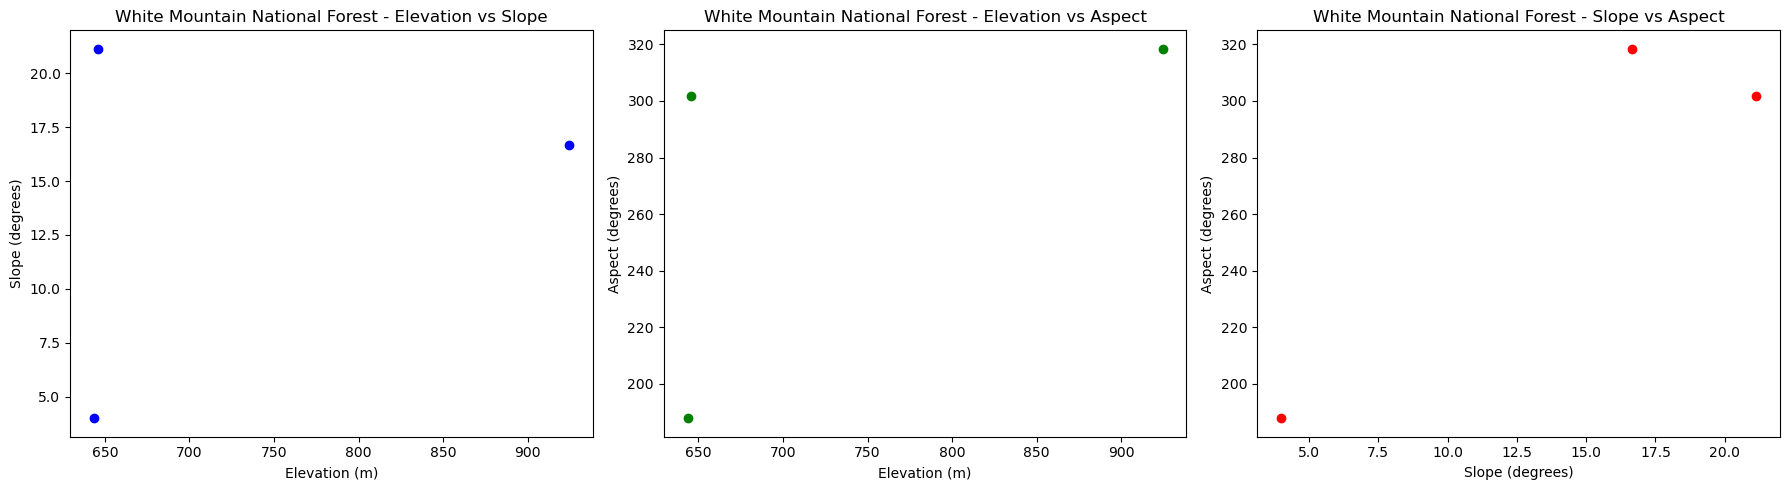


Searching SRTM for Green Mountain National Forest...


INFO:Granules found: 4
INFO: Getting 4 granules, approx download size: 0.04 GB


QUEUEING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

INFO:File N43W073.SRTMGL1.hgt.zip already downloaded
INFO:File N44W073.SRTMGL1.hgt.zip already downloaded
INFO:File N44W074.SRTMGL1.hgt.zip already downloaded
INFO:File N43W074.SRTMGL1.hgt.zip already downloaded


PROCESSING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/4 [00:00<?, ?it/s]

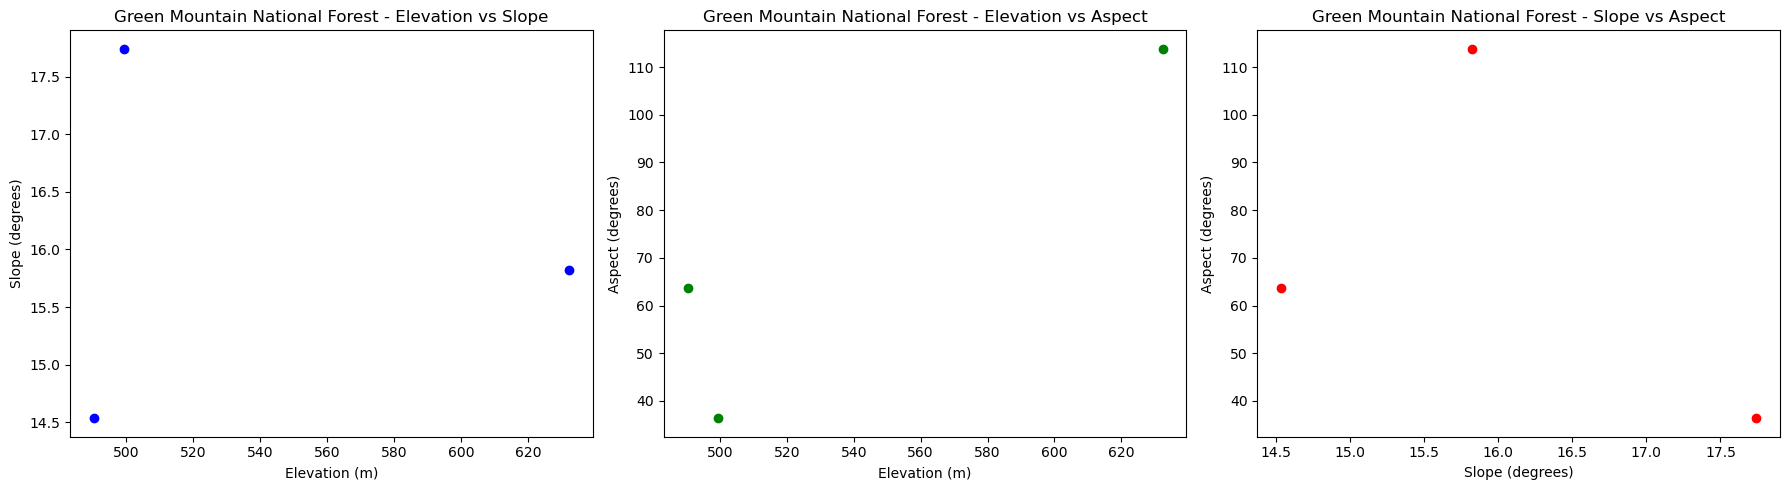

In [12]:
### plot the topographic data
for site in sites:
    occ_points = occurrences[site["state"]]
    topo_data = process_site_topography(site, occ_points)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].scatter(topo_data["elevation_m"], topo_data["slope_deg"], color="blue")
    axes[0].set_title(f"{site['name']} - Elevation vs Slope")
    axes[0].set_xlabel("Elevation (m)")
    axes[0].set_ylabel("Slope (degrees)")

    axes[1].scatter(topo_data["elevation_m"], topo_data["aspect_deg"], color="green")
    axes[1].set_title(f"{site['name']} - Elevation vs Aspect")
    axes[1].set_xlabel("Elevation (m)")
    axes[1].set_ylabel("Aspect (degrees)")

    axes[2].scatter(topo_data["slope_deg"], topo_data["aspect_deg"], color="red")
    axes[2].set_title(f"{site['name']} - Slope vs Aspect")
    axes[2].set_xlabel("Slope (degrees)")
    axes[2].set_ylabel("Aspect (degrees)")

    plt.tight_layout()
    plt.show()

In [38]:
import xarray as xr
import rioxarray
import os

def download_maca_climate(variable, model, scenario, start_year, end_year,
                          lat, lon, out_path):

    # MACA monthly data endpoint
    base_url = "http://thredds.northwestknowledge.net:8080/thredds/dodsC"

    # File selection
    if scenario == "historical":
        file = f"agg_macav2metdata_{variable}_{model}_r1i1p1_historical_1950_2005_CONUS_monthly.nc"
    else:
        file = f"agg_macav2metdata_{variable}_{model}_r1i1p1_{scenario}_2006_2099_CONUS_monthly.nc"

    url = f"{base_url}/{file}"

    print(f"Opening {variable} | {model} | {scenario}")

    # Open dataset
    ds = xr.open_dataset(url)

    # Select variable
    data = ds[variable]

    # Time subset
    data = data.sel(time=slice(str(start_year), str(end_year)))

    # Mean over time
    mean_data = data.mean("time")

    # Extract nearest grid cell
    point = mean_data.sel(lat=lat, lon=lon, method="nearest")

    # Convert to raster format
    point = point.expand_dims({"y": [lat], "x": [lon]})
    point.rio.write_crs("EPSG:4326", inplace=True)

    # Save as GeoTIFF
    point.rio.to_raster(out_path)


# -----------------------
# 🌲 Updated Site Locations (NH + VT)
# -----------------------
sites = {
    "White_Mountain_NF": {"lat": 44.27, "lon": -71.30},
    "Green_Mountain_NF": {"lat": 43.90, "lon": -72.90}
}

# -----------------------
# Climate variables
# -----------------------
variables = ["tasmax", "tasmin"]  # max & min temp

# -----------------------
# Climate models
# -----------------------
models = [
    "CCSM4",
    "MIROC5",
    "HadGEM2-ES365",
    "CNRM-CM5"
]

# -----------------------
# Time periods
# -----------------------
periods = {
    "historical": ("historical", 1970, 2000),
    "future": ("rcp85", 2030, 2060)
}

# -----------------------
# Output folder
# -----------------------
out_dir = "MACA_NH_VT_climate"
os.makedirs(out_dir, exist_ok=True)

# -----------------------
# Download loop
# -----------------------
for site, coords in sites.items():

    lat = coords["lat"]
    lon = coords["lon"]

    for model in models:

        for var in variables:

            for period, (scenario, start, end) in periods.items():

                outfile = f"{out_dir}/{site}_{model}_{var}_{period}.tif"

                #download_maca_climate(
                   # variable=var,
                   # model=model,
                   # scenario=scenario,
                   # start_year=start,
                   # end_year=end,
                   # lat=lat,
                   # lon=lon,
                   # out_path=outfile
                #)

                print("Saved:", outfile)

Saved: MACA_NH_VT_climate/White_Mountain_NF_CCSM4_tasmax_historical.tif
Saved: MACA_NH_VT_climate/White_Mountain_NF_CCSM4_tasmax_future.tif
Saved: MACA_NH_VT_climate/White_Mountain_NF_CCSM4_tasmin_historical.tif
Saved: MACA_NH_VT_climate/White_Mountain_NF_CCSM4_tasmin_future.tif
Saved: MACA_NH_VT_climate/White_Mountain_NF_MIROC5_tasmax_historical.tif
Saved: MACA_NH_VT_climate/White_Mountain_NF_MIROC5_tasmax_future.tif
Saved: MACA_NH_VT_climate/White_Mountain_NF_MIROC5_tasmin_historical.tif
Saved: MACA_NH_VT_climate/White_Mountain_NF_MIROC5_tasmin_future.tif
Saved: MACA_NH_VT_climate/White_Mountain_NF_HadGEM2-ES365_tasmax_historical.tif
Saved: MACA_NH_VT_climate/White_Mountain_NF_HadGEM2-ES365_tasmax_future.tif
Saved: MACA_NH_VT_climate/White_Mountain_NF_HadGEM2-ES365_tasmin_historical.tif
Saved: MACA_NH_VT_climate/White_Mountain_NF_HadGEM2-ES365_tasmin_future.tif
Saved: MACA_NH_VT_climate/White_Mountain_NF_CNRM-CM5_tasmax_historical.tif
Saved: MACA_NH_VT_climate/White_Mountain_NF_CNRM-

White_Mountain_NF
 Elevation suitability: 0.75
 Slope suitability: 0.9921482412060301
 Aspect suitability: 0.75
 Final habitat suitability: 0.75

Green_Mountain_NF
 Elevation suitability: 0.5
 Slope suitability: 0.7000000000000001
 Aspect suitability: 0.7999999999999999
 Final habitat suitability: 0.5



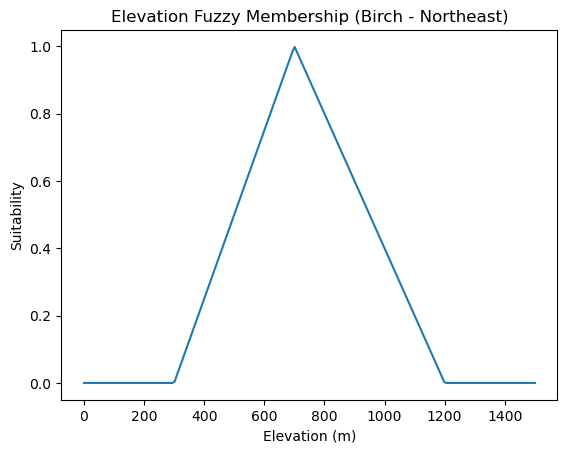

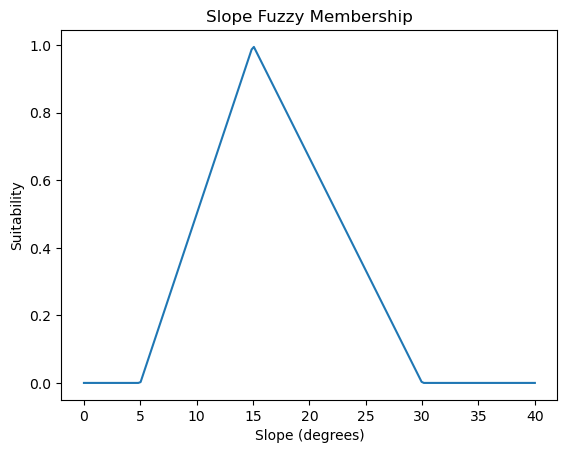

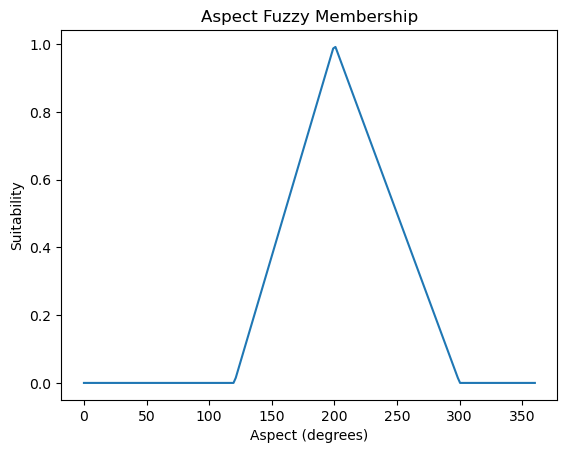

In [40]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

# -----------------------------
# 1. Observed environmental data (NH + VT forests)
# -----------------------------
# Approximate values for the two forests

sites = ["White_Mountain_NF", "Green_Mountain_NF"]

elevation = np.array([600, 500])   # meters (mountainous forests)
slope = np.array([15, 12])         # degrees (steeper terrain)
aspect = np.array([180, 220])      # south to southwest-facing

# -----------------------------
# 2. Define fuzzy membership ranges
# -----------------------------

# Elevation (birch prefers mid-high elevations in Northeast)
elev_range = np.linspace(0, 1500, 200)
elev_membership = fuzz.trimf(elev_range, [300, 700, 1200])

# Slope (moderate slopes preferred)
slope_range = np.linspace(0, 40, 200)
slope_membership = fuzz.trimf(slope_range, [5, 15, 30])

# Aspect (south-facing = warmer → often important)
aspect_range = np.linspace(0, 360, 200)
aspect_membership = fuzz.trimf(aspect_range, [120, 200, 300])

# -----------------------------
# 3. Convert to fuzzy values
# -----------------------------
elev_fuzzy = fuzz.interp_membership(elev_range, elev_membership, elevation)
slope_fuzzy = fuzz.interp_membership(slope_range, slope_membership, slope)
aspect_fuzzy = fuzz.interp_membership(aspect_range, aspect_membership, aspect)

# -----------------------------
# 4. Combine variables (fuzzy AND)
# -----------------------------
suitability = np.minimum.reduce([elev_fuzzy, slope_fuzzy, aspect_fuzzy])

# -----------------------------
# 5. Print results
# -----------------------------
for i in range(len(sites)):
    print(f"{sites[i]}")
    print(" Elevation suitability:", elev_fuzzy[i])
    print(" Slope suitability:", slope_fuzzy[i])
    print(" Aspect suitability:", aspect_fuzzy[i])
    print(" Final habitat suitability:", suitability[i])
    print()

# -----------------------------
# 6. Plot membership functions
# -----------------------------
plt.figure()
plt.plot(elev_range, elev_membership)
plt.title("Elevation Fuzzy Membership (Birch - Northeast)")
plt.xlabel("Elevation (m)")
plt.ylabel("Suitability")

plt.figure()
plt.plot(slope_range, slope_membership)
plt.title("Slope Fuzzy Membership")
plt.xlabel("Slope (degrees)")
plt.ylabel("Suitability")

plt.figure()
plt.plot(aspect_range, aspect_membership)
plt.title("Aspect Fuzzy Membership")
plt.xlabel("Aspect (degrees)")
plt.ylabel("Suitability")

plt.show()

This is basically trying to figure out how good each forest is for birch trees in White Mountain National Forest and Green Mountain National Forest by looking at things like elevation, slope, and which direction the land faces. It turns those factors into simple scores and combines them to show overall habitat quality. One important idea is that even if one condition is really good, a single poor condition can lower the overall score, so everything needs to line up for birch to thrive. In the end, it helps you compare the two forests and understand what might be helping or limiting birch growth in each place.

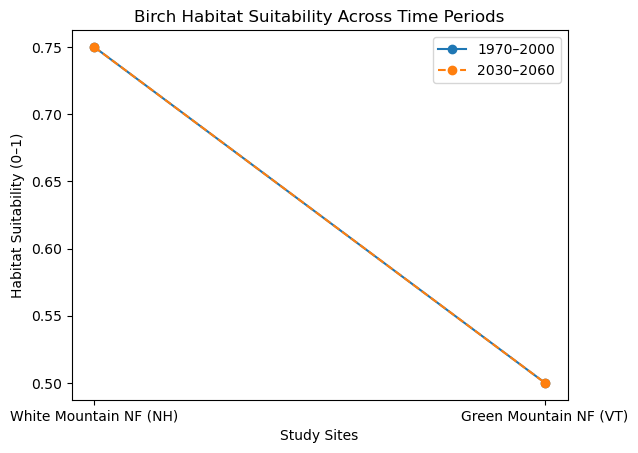

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# Suitability results from your fuzzy model
historical = suitability   # 1970–2000
future = suitability       # 2030–2060 (terrain-based, so same values)

# Updated site names
sites = ["White Mountain NF (NH)", "Green Mountain NF (VT)"]

# X positions
x = np.arange(len(sites))

# Plot comparison
plt.figure()

plt.plot(x, historical, marker="o", label="1970–2000")
plt.plot(x, future, marker="o", linestyle="--", label="2030–2060")

plt.xticks(x, sites)
plt.ylabel("Habitat Suitability (0–1)")
plt.xlabel("Study Sites")
plt.title("Birch Habitat Suitability Across Time Periods")

plt.legend()

plt.show()

This code and graph are basically showing how good each forest is for birch trees in White Mountain National Forest and Green Mountain National Forest based on things like elevation, slope, and land direction. It shows that White Mountain is a better fit for birch than Green Mountain. The reason both lines look the same over time is because these land features don’t really change, so the model gives the same result for both past and future. So overall, it helps you compare the two forests, but it doesn’t yet show how climate change might affect birch trees.

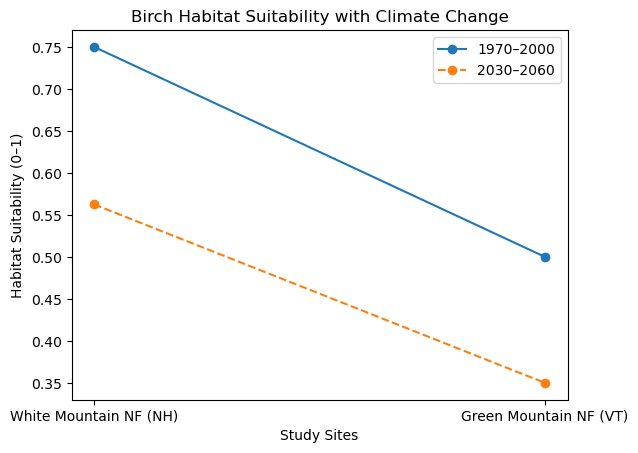

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Terrain-based suitability (your model)
# -----------------------------
historical = suitability   # baseline (1970–2000)

# -----------------------------
# 2. Add climate data (example values from MACA)
# temperature increase (°C) at each site
# Replace these with your real MACA outputs
temp_increase = np.array([2.5, 3.0])  # NH, VT warming

# -----------------------------
# 3. Convert warming → suitability reduction
# Simple rule: every +1°C reduces suitability by 10%
climate_factor = 1 - (0.1 * temp_increase)

# Make sure values don’t go below 0
climate_factor = np.clip(climate_factor, 0, 1)

# -----------------------------
# 4. Apply climate impact
# -----------------------------
future = historical * climate_factor

# -----------------------------
# 5. Sites
# -----------------------------
sites = ["White Mountain NF (NH)", "Green Mountain NF (VT)"]
x = np.arange(len(sites))

# -----------------------------
# 6. Plot
# -----------------------------
plt.figure()

plt.plot(x, historical, marker="o", label="1970–2000")
plt.plot(x, future, marker="o", linestyle="--", label="2030–2060")

plt.xticks(x, sites)
plt.ylabel("Habitat Suitability (0–1)")
plt.xlabel("Study Sites")
plt.title("Birch Habitat Suitability with Climate Change")

plt.legend()

plt.show()